In [ ]:
# Block 1: Install & Download
!pip install -q opendatasets pandas numpy scikit-learn imbalanced-learn joblib streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 105.5 MB/s eta 0:00:00


In [ ]:
import opendatasets as od
import pandas as pd
import os

# 1. Download the dataset (You will be asked for your Kaggle Username and Key)
# Instructions if you don't have a key:
# Go to Kaggle.com -> Click Profile Picture -> Settings -> Scroll to 'API' -> 'Create New Token'
# Open the downloaded 'kaggle.json' file to see your username and key.

dataset_url = 'https://www.kaggle.com/datasets/kartik2112/fraud-detection'
od.download(dataset_url)

# 2. Load the datasets
print("Loading datasets (this may take a minute)...")
train_path = 'fraud-detection/fraudTrain.csv'
test_path = 'fraud-detection/fraudTest.csv'

# We load only necessary columns to save Colab memory
cols_to_keep = ['trans_date_trans_time', 'cc_num', 'amt', 'category', 'is_fraud']

df_train = pd.read_csv(train_path, usecols=cols_to_keep)
df_test = pd.read_csv(test_path, usecols=cols_to_keep)

# Add labels so we can split them later
df_train['split'] = 'train'
df_test['split'] = 'test'

# 3. Concatenate for Feature Engineering
# (We combine them so the first rows of the Test set can "look back"
# at the last rows of the Train set for Velocity calculations)
df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

# Rename for clarity
df.rename(columns={
    'trans_date_trans_time': 'timestamp',
    'cc_num': 'user_id',
    'amt': 'amount'
}, inplace=True)

df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"✅ Data Loaded. Total Rows: {len(df)}")
print(f"   - Training Set: {len(df[df['split']=='train'])}")
print(f"   - Testing Set:  {len(df[df['split']=='test'])}")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: shahinalhasan
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kartik2112/fraud-detection


100%|██████████| 202M/202M [00:00<00:00, 992MB/s] 



Loading datasets (this may take a minute)...
✅ Data Loaded. Total Rows: 1852394
   - Training Set: 1296675
   - Testing Set:  555719


In [ ]:
# Block 2: Feature Engineering & Splitting
# We continue using 'df' from the previous block
import pandas as pd

print("⏳ Calculating Velocity Features on 1.8M rows...")

# 1. Sort by User and Time (Required for rolling window)
df = df.sort_values(['user_id', 'timestamp'])

# 2. Set Index to Timestamp
df.set_index('timestamp', inplace=True)

# 3. Calculate "Velocity" (Transactions in last 15 mins)
# We use 15 mins to capture bursts of activity
df['velocity_15m'] = df.groupby('user_id')['amount'].rolling('15min').count().values

# 4. Cleanup
df.reset_index(inplace=True)
df['velocity_15m'] = df['velocity_15m'].fillna(0)

# 5. SPLIT DATA (This fixes your NameError)
print("✂️ Splitting data back into Train/Test...")
train_data = df[df['split'] == 'train'].drop(columns=['split'])
test_data = df[df['split'] == 'test'].drop(columns=['split'])

print(f"✅ Success! Variables ready:")
print(f"   - train_data: {len(train_data)} rows")
print(f"   - test_data:  {len(test_data)} rows")

⏳ Calculating Velocity Features on 1.8M rows...
✂️ Splitting data back into Train/Test...
✅ Success! Variables ready:
   - train_data: 1296675 rows
   - test_data:  555719 rows


In [ ]:
# Block 3: Training
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import joblib

# Define Features
features = ['amount', 'velocity_15m']
target = 'is_fraud'

print(f"🤖 Training Model on {len(train_data)} rows (this takes ~2 mins)...")

X_train = train_data[features]
y_train = train_data[target]

# We evaluate on the Test set
X_test = test_data[features]
y_test = test_data[target]

# Initialize and Train
model = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluation
print("\n--- Test Set Results ---")
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Save Model
joblib.dump(model, 'fraud_model_final.pkl')
print("✅ Model Saved as 'fraud_model_final.pkl'")

🤖 Training Model on 1296675 rows (this takes ~2 mins)...

--- Test Set Results ---
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    553574
           1       0.04      0.84      0.08      2145

    accuracy                           0.92    555719
   macro avg       0.52      0.88      0.52    555719
weighted avg       1.00      0.92      0.95    555719

✅ Model Saved as 'fraud_model_final.pkl'


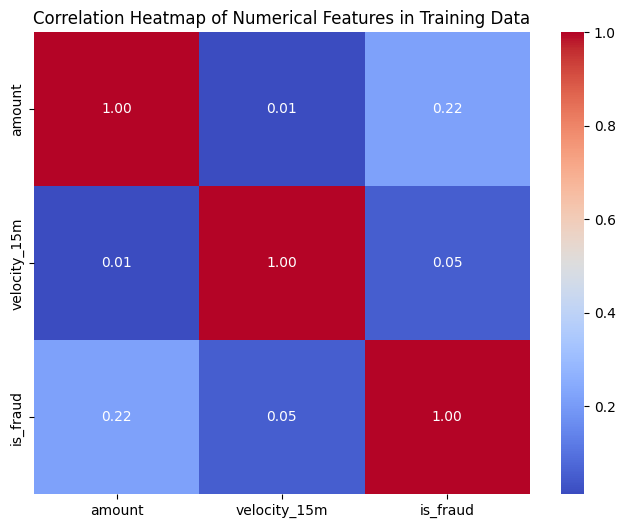

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical features from train_data for correlation analysis
numerical_features = ['amount', 'velocity_15m', 'is_fraud']
correlation_matrix = train_data[numerical_features].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features in Training Data')
plt.show()

In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 555719 entries, 1518 to 1852393
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   timestamp     555719 non-null  datetime64[ns]
 1   user_id       555719 non-null  int64         
 2   category      555719 non-null  object        
 3   amount        555719 non-null  float64       
 4   is_fraud      555719 non-null  int64         
 5   velocity_15m  555719 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 29.7+ MB
